In [1]:
import pandas as pd



sana = pd.read_csv("Indian_Employee_Data.csv")



In [2]:
sana.head()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
0,EMP001,Rajesh Kumar,32.0,Male,Engineering,Senior Developer,850000.0,8.0,Bangalore,Karnataka,B.Tech,4.2,03/15/2016,12.0,45.0
1,EMP002,Priya Sharma,28.0,Female,Marketing,Marketing Manager,720000.0,5.0,Mumbai,Maharashtra,MBA,4.5,01/20/2019,8.0,32.0
2,EMP003,Amit Singh,35.0,Male,Finance,Financial Analyst,650000.0,10.0,Delhi,Delhi,CA,3.8,07/10/2014,15.0,28.0
3,EMP004,Sneha Patel,26.0,Female,NaN,HR Executive,480000.0,3.0,Ahmedabad,Gujarat,MBA,4.1,05/12/2021,6.0,20.0
4,EMP005,Vikram Reddy,40.0,Male,Engineering,Tech Lead,1200000.0,15.0,Hyderabad,Telangana,M.Tech,4.7,11/08/2009,25.0,55.0


In [3]:
sana.tail()


,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
44,EMP045,Neha Kapoor,28.0,Female,IT,Data Analyst,NaN,4.0,Bangalore,Karnataka,M.Sc,3.8,04/12/2020,6.0,29.0
45,EMP046,Amit Sharma,27.0,Male,IT,Junior Developer,650000.0,4.0,Delhi,NaN,B.Tech,4.5,08/20/2020,5.0,25.0
46,EMP047,Riya Gupta,32.0,Female,HR,HR Specialist,NaN,8.0,Mumbai,Maharashtra,MBA,NaN,11/03/2016,inf,42.0
47,EMP048,Rohit Bansal,36.0,Male,Finance,Senior Analyst,980000.0,12.0,Mumbai,Maharashtra,CA,4.9,03/20/2012,19.0,51.0
48,EMP049,Sneha Tiwari,25.0,Female,Sales,Sales Representative,inf,2.0,Kolkata,West Bengal,B.Com,3.6,05/14/2022,3.0,16.0


In [4]:
sana.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         49 non-null     object 
 1   Name                49 non-null     object 
 2   Age                 47 non-null     float64
 3   Gender              49 non-null     object 
 4   Department          48 non-null     object 
 5   Position            48 non-null     object 
 6   Salary              44 non-null     float64
 7   Experience_Years    47 non-null     float64
 8   City                49 non-null     object 
 9   State               46 non-null     object 
 10  Education           49 non-null     object 
 11  Performance_Rating  45 non-null     float64
 12  Joining_Date        48 non-null     object 
 13  Projects_Completed  48 non-null     float64
 14  Overtime_Hours      48 non-null     float64
dtypes: float64(6), object(9)
memory usage: 5.9+ KB


In [5]:
print(sana.describe())

             Age     Salary  Experience_Years  Performance_Rating  \
count  47.000000       44.0              47.0           45.000000   
mean   32.914894        inf               inf            4.295556   
std     6.990148        NaN               NaN            0.401110   
min    23.000000   -45000.0               2.0            3.500000   
25%    28.000000   642500.0               4.0            4.000000   
50%    31.000000   765000.0               7.0            4.300000   
75%    36.000000  1062500.0              10.0            4.600000   
max    55.000000        inf               inf            5.000000   

       Projects_Completed  Overtime_Hours  
count               48.00            48.0  
mean                  inf             inf  
std                   NaN             NaN  
min                  2.00            12.0  
25%                  7.00            28.0  
50%                 12.00            37.0  
75%                 18.25            46.5  
max                   inf 

In [6]:
import numpy as np

# Find missing values
print(sana[['Name', 'Department', 'Salary']].isnull().sum())

# Remove errors (replace infinity with NaN)
sana['Salary'] = sana['Salary'].replace([np.inf, -np.inf], np.nan)

# Fill missing values
sana['Name'] = sana['Name'].fillna(sana['Name'].mode()[0])
sana['Department'] = sana['Department'].fillna(sana['Department'].mode()[0])
sana['Salary'] = sana['Salary'].fillna(sana['Salary'].mean())

# Check again
print(sana[['Name', 'Department', 'Salary']].isnull().sum())

Name          0
Department    1
Salary        5
dtype: int64
Name          0
Department    0
Salary        0
dtype: int64


In [7]:
print(sana['Department'].value_counts())

Department
IT             11
Engineering     8
Finance         7
HR              6
Sales           5
Marketing       4
Operations      4
Design          2
Management      2
Name: count, dtype: int64


In [8]:
print(sana['Salary'].mean())

947738.0952380951


In [9]:
print("Highest Salary:", sana['Salary'].max())
print("Lowest Salary:", sana['Salary'].min())

Highest Salary: 5000000.0
Lowest Salary: -45000.0


In [10]:
print(sana.groupby('Department').size())

Department
Design          2
Engineering     8
Finance         7
HR              6
IT             11
Management      2
Marketing       4
Operations      4
Sales           5
dtype: int64


In [11]:
group = sana.groupby('Department')

for dept, data in group:
    print(dept)
    print(data)

Design
   Employee_ID          Name   Age  Gender Department          Position  \
7       EMP008   Meera Joshi  27.0  Female     Design    UI/UX Designer   
17      EMP018  Sonia Kapoor  26.0  Female     Design  Graphic Designer   

      Salary  Experience_Years        City      State Education  \
7   620000.0               4.0   Bangalore  Karnataka     B.Des   
17  420000.0               3.0  Chandigarh     Punjab     B.Des   

    Performance_Rating Joining_Date  Projects_Completed  Overtime_Hours  
7                  4.4   08/03/2020                 7.0            25.0  
17                 4.0   07/08/2021                 5.0            18.0  
Engineering
   Employee_ID           Name   Age  Gender   Department  \
0       EMP001   Rajesh Kumar  32.0    Male  Engineering   
4       EMP005   Vikram Reddy  40.0    Male  Engineering   
6       EMP007    Arjun Gupta  31.0    Male  Engineering   
10      EMP011    Suresh Iyer  42.0    Male  Engineering   
13      EMP014      Divya Rao  

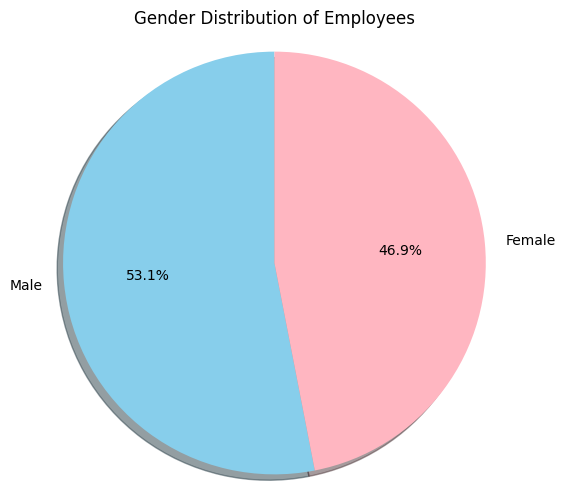

In [12]:
import matplotlib.pyplot as plt

gender = sana['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=['skyblue', 'lightpink']
)

plt.title("Gender Distribution of Employees")
plt.axis('equal')

plt.show()

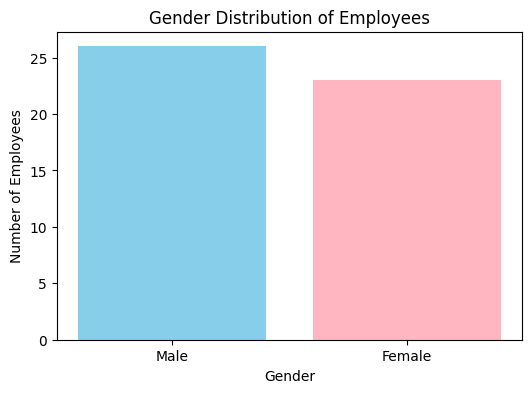

In [13]:
import matplotlib.pyplot as plt

gender = sana['Gender'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(gender.index, gender.values, color=['skyblue', 'lightpink'])

plt.title("Gender Distribution of Employees")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.show()

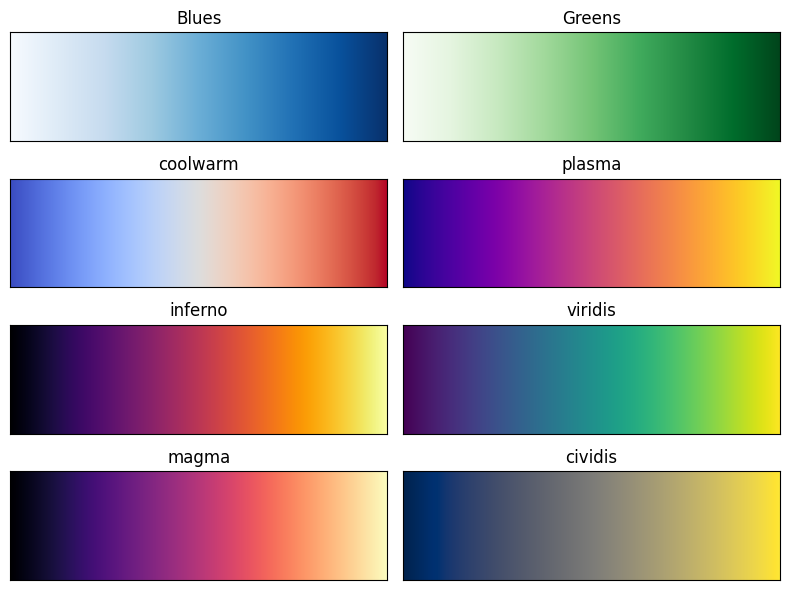

In [14]:
import matplotlib.pyplot as plt
import numpy as np

gradient = np.linspace(0, 1, 256).reshape(1, -1)

cmaps = ['Blues', 'Greens', 'coolwarm', 'plasma',
         'inferno', 'viridis', 'magma', 'cividis']

fig, axs = plt.subplots(4, 2, figsize=(8, 6))

for ax, cmap in zip(axs.ravel(), cmaps):
    ax.imshow(gradient, aspect='auto', cmap=cmap)
    ax.set_title(cmap)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

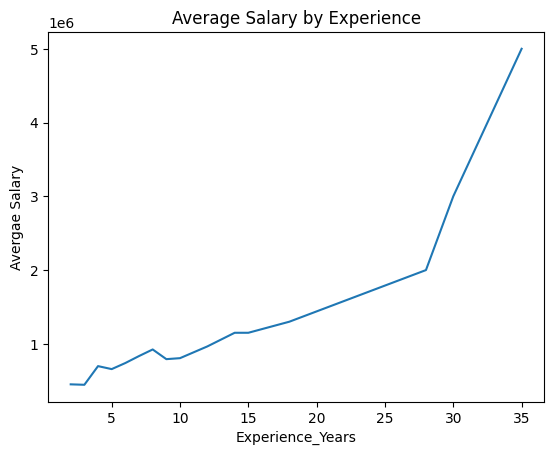

In [15]:
salary_exp = sana.groupby("Experience_Years")["Salary"].mean()

plt.plot(salary_exp.index,salary_exp.values)

plt.xlabel("Experience_Years")
plt.ylabel("Avergae Salary")
plt.title("Average Salary by Experience")

plt.show()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus

from sklearn.metrics import ( mean_absolute_error, mean_squared_error,r2_score)

import warnings
warnings.filterwarnings('ignore')

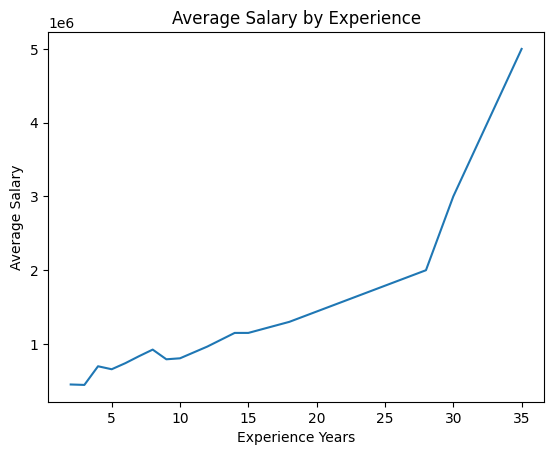

In [17]:
salary_exp = sana.groupby("Experience_Years")["Salary"].mean()

plt.plot(salary_exp.index, salary_exp.values)

plt.xlabel("Experience Years")
plt.ylabel("Average Salary")
plt.title("Average Salary by Experience")

plt.show()

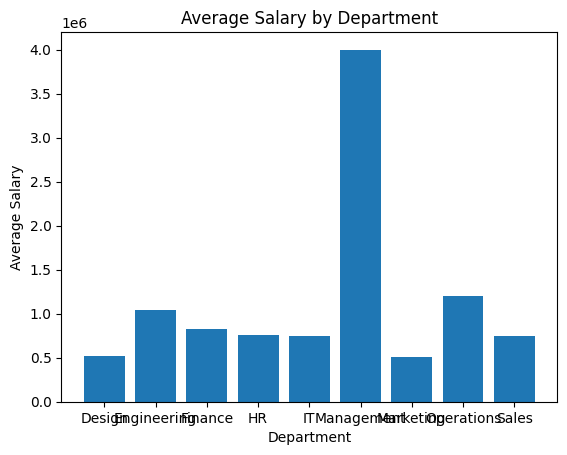

In [18]:
salary_dept = sana.groupby("Department")["Salary"].mean()

plt.bar(salary_dept.index, salary_dept.values)

plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.title("Average Salary by Department")

plt.show()

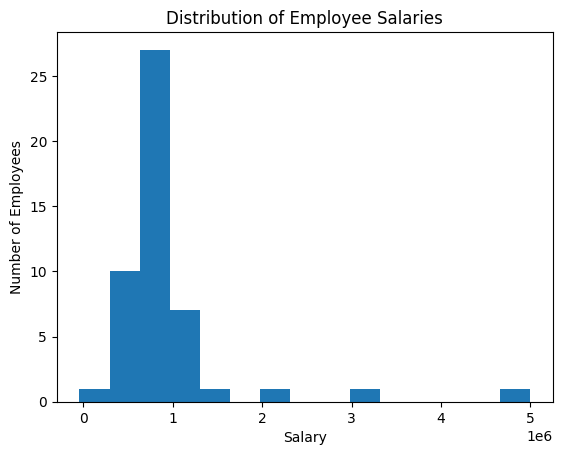

In [19]:
plt.hist(sana["Salary"], bins=15)

plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.title("Distribution of Employee Salaries")

plt.show()

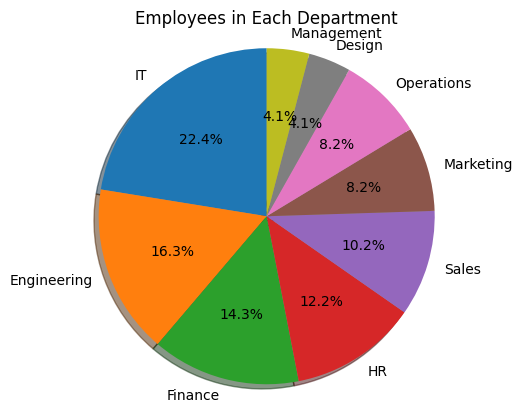

In [20]:
dept = sana["Department"].value_counts()

plt.pie(
    dept.values,
    labels=dept.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Employees in Each Department")
plt.axis("equal")

plt.show()

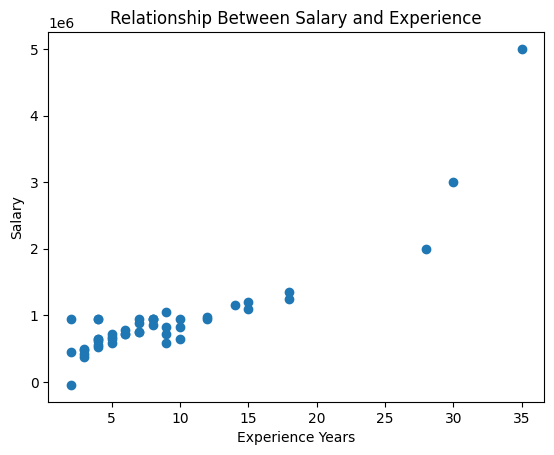

In [21]:
plt.scatter(sana["Experience_Years"], sana["Salary"])

plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Relationship Between Salary and Experience")

plt.show()

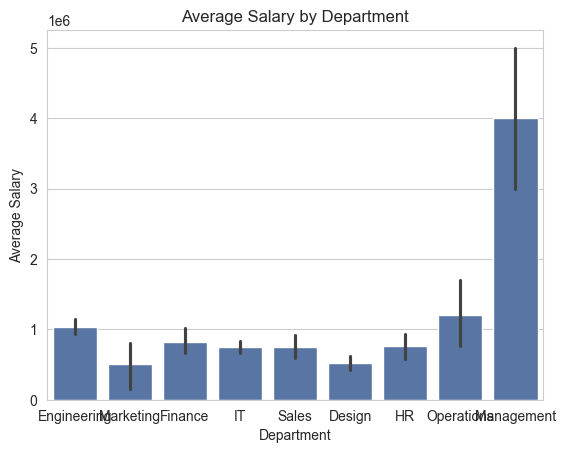

In [23]:
sns.set_style("whitegrid")
sns.set_palette("deep")
sns.barplot(data=sana,x="Department",y="Salary")
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

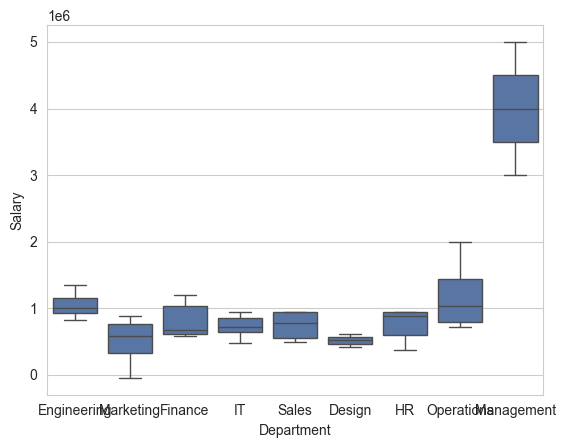

In [26]:
sns.boxplot(data=sana,x="Department",y="Salary")
plt.show()

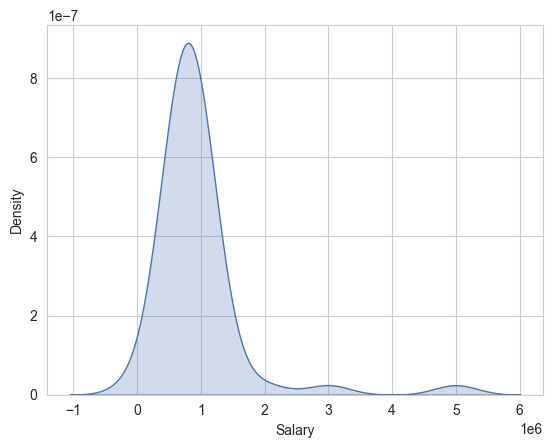

In [29]:
sns.kdeplot(data=sana,x="Salary",shade=True)
plt.show()

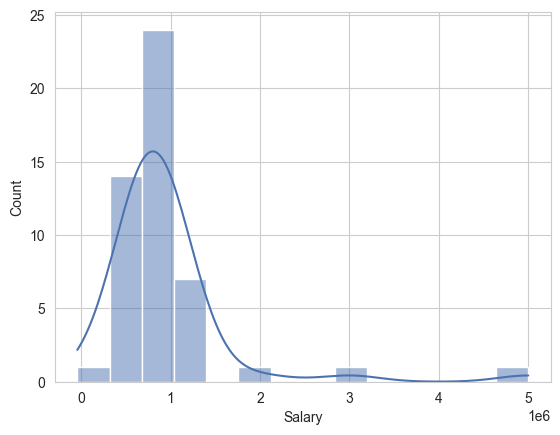

In [31]:
sns.histplot(data=sana,x="Salary",kde=True)
plt.show()

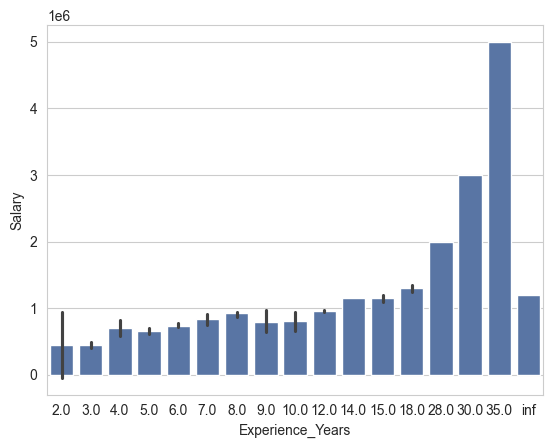

In [32]:
sns.barplot(data=sana,x="Experience_Years",y="Salary")
plt.show()

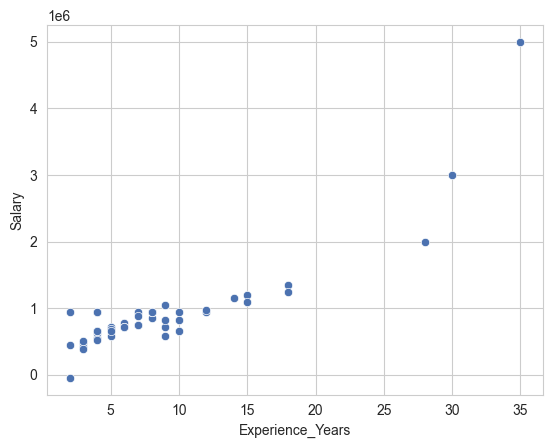

In [33]:
sns.scatterplot(data=sana,x="Experience_Years",y="Salary")
plt.show()

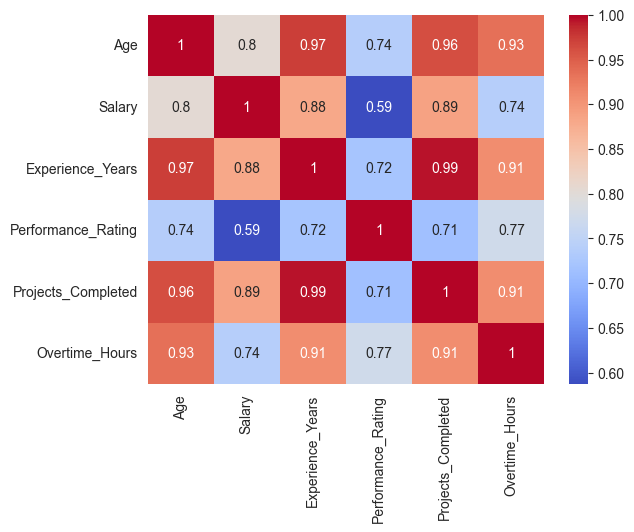

In [35]:
sns.heatmap(sana.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [36]:
correlation = sana.corr(numeric_only=True)
print(correlation)

                         Age    Salary  Experience_Years  Performance_Rating  \
Age                 1.000000  0.803312          0.973331            0.737859   
Salary              0.803312  1.000000          0.881332            0.586837   
Experience_Years    0.973331  0.881332          1.000000            0.722293   
Performance_Rating  0.737859  0.586837          0.722293            1.000000   
Projects_Completed  0.961485  0.887635          0.994832            0.712924   
Overtime_Hours      0.934710  0.739370          0.908405            0.773757   

                    Projects_Completed  Overtime_Hours  
Age                           0.961485        0.934710  
Salary                        0.887635        0.739370  
Experience_Years              0.994832        0.908405  
Performance_Rating            0.712924        0.773757  
Projects_Completed            1.000000        0.908197  
Overtime_Hours                0.908197        1.000000  
